In [21]:
import pandas as pd

data = pd.read_csv('igra_v2_data.csv')
stations = pd.read_csv('station.csv')
stations = stations.rename(columns={'WMO ID': 'wmo_id', 'Latitude': 'lat', 'Longitude': 'lon'})

In [27]:
# Ensure 'wmo_id' is the same type in both DataFrames for merging
data['wmo_id'] = data['wmo_id'].astype(str)
stations['wmo_id'] = stations['wmo_id'].astype(str)

# Perform the Merge (Left Join)
# This keeps all your atmospheric data and attaches the coordinates
df_merged = pd.merge(data, stations, on='wmo_id', how='left')

In [27]:
data.isna().sum()

lvl_type1            0
lvl_type2            0
etime         15587201
press          5682881
gph            7251951
temp          10300878
rh            15458509
dpdp          11763984
wdir           3230705
wspd           3230705
station_id           0
year                 0
month                0
day                  0
hour                 0
reltime              0
numlev               0
p_src           789705
np_src         1413952
lat                  0
lon                  0
press_hpa      5682881
dtype: int64

In [22]:
df = data.drop(columns=['etime','reltime','p_src','np_src','rh'])

In [25]:
# Create a categorical tag for the level type
df['record_type'] = 'other'

# PIBAL/Wind-only levels (Type 3)
df.loc[df['lvl_type1'] == 3, 'record_type'] = 'PIBAL'

# Radiosonde/Thermo levels (Type 1 or 2)
df.loc[df['lvl_type1'].isin([1, 2]), 'record_type'] = 'Radiosonde'

In [28]:
df_rason = df[df['record_type'] == 'Radiosonde']

In [36]:
print(df_rason.head())
print("")
print(df_rason.isna().sum())

    lvl_type1  lvl_type2    press  gph  temp  dpdp   wdir  wspd   station_id  \
89          1          0  85000.0  NaN   NaN   NaN   60.0   2.5  IDM00096015   
90          1          0  20000.0  NaN   NaN   NaN   95.0  24.2  IDM00096015   
91          1          0  15000.0  NaN   NaN   NaN  100.0  34.5  IDM00096015   
92          1          0  10000.0  NaN   NaN   NaN   60.0  26.2  IDM00096015   
93          1          0   7000.0  NaN   NaN   NaN   85.0  13.9  IDM00096015   

    year  month  day  hour  numlev   lat      lon  press_hpa record_type  
89  1995      7    8    12      14  4.25  96.1167      850.0  Radiosonde  
90  1995      7    8    12      14  4.25  96.1167      200.0  Radiosonde  
91  1995      7    8    12      14  4.25  96.1167      150.0  Radiosonde  
92  1995      7    8    12      14  4.25  96.1167      100.0  Radiosonde  
93  1995      7    8    12      14  4.25  96.1167       70.0  Radiosonde  

lvl_type1            0
lvl_type2            0
press                0

In [35]:
# Ensure flights are ordered by ascending altitude (descending pressure)
df_rason = df_rason.sort_values(['station_id', 'year', 'month', 'day', 'hour', 'press'], 
                               ascending=[True, True, True, True, True, False])

In [80]:
df_training = df_rason.dropna(subset=['press', 'temp','dpdp','wspd','wdir']).copy()


In [81]:
df_training = df_training.drop(columns=['record_type', 'lvl_type1', 'lvl_type2'])

In [82]:
import numpy as np

def fill_gph_hypsometric(df):
    R_d = 287.05  
    g = 9.80665   

    # 1. Sort globally first
    df = df.sort_values(['station_id', 'year', 'month', 'day', 'hour', 'press'], 
                        ascending=[True, True, True, True, True, False])

    # 2. Calculate Virtual Temperature for the WHOLE dataframe first
    temp_k = df['temp'] + 273.15
    dewpoint_k = (df['temp'] - df['dpdp']) + 273.15

    # Standard formula for vapor pressure (hPa)
    e = 6.112 * np.exp((17.67 * (dewpoint_k - 273.15)) / (dewpoint_k - 29.65))
    
    # Virtual Temp Formula: Tv = T * (1 + 0.61 * q) -> approx with e/p
    df['vt'] = temp_k * (1 + 0.61 * (e / (df['press_hpa']))) 

    def interpolate_flight_gph(group):
        # We work on a copy to avoid SettingWithCopyWarnings
        group = group.copy()
        
        # Iterate through the group
        for i in range(1, len(group)):
            # If current GPH is NaN, calculate it from the one below
            if pd.isna(group.iloc[i]['gph']):
                # Previous row (i-1) must have a GPH to calculate current (i)
                if not pd.isna(group.iloc[i-1]['gph']):
                    p1 = group.iloc[i-1]['press_hpa']
                    p2 = group.iloc[i]['press_hpa']
                    
                    # Use .iloc to get values from the group, then calculate dz
                    tv1 = group.iloc[i-1]['vt']
                    tv2 = group.iloc[i]['vt']
                    tv_avg = (tv1 + tv2) / 2
                    
                    # Hypsometric Equation
                    dz = (R_d * tv_avg / g) * np.log(p1 / p2)
                    
                    # Set the value
                    group.iloc[i, group.columns.get_loc('gph')] = group.iloc[i-1]['gph'] + dz
        return group

    # 3. Apply the fix
    df = df.groupby(['station_id', 'year', 'month', 'day', 'hour'], group_keys=False).apply(interpolate_flight_gph)
    
    # Drop the temporary virtual temp column
    return df.drop(columns=['vt'])

# Run it
df_training = fill_gph_hypsometric(df_training)

C:\Users\ahlil\AppData\Local\Temp\ipykernel_24832\553506801.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['station_id', 'year', 'month', 'day', 'hour'], group_keys=False).apply(interpolate_flight_gph)


In [83]:
def anchor_and_fix_gph(df):
    # 1. Fill any GPH at the very bottom of a flight using Standard Atmosphere
    # Formula: z = 44330 * (1 - (p/1013.25)^(1/5.255))
    mask = df['gph'].isna()
    p_hpa = df['press_hpa']
    df.loc[mask, 'gph'] = 44330 * (1 - (p_hpa / 1013.25)**(1/5.255))
    
    # 2. Now that every row has at least an estimate or a real value, 
    # we run a quick linear interpolation ONLY for GPH within each flight
    # to smooth out any small gaps left behind.
    df['gph'] = df.groupby(['station_id', 'year', 'month', 'day', 'hour'])['gph'].transform(
        lambda x: x.interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')
    )
    return df

df_training = anchor_and_fix_gph(df_training)

C:\Users\ahlil\AppData\Local\Temp\ipykernel_24832\3075527970.py:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')


In [84]:
# Calculate the number of levels for each flight
flight_lengths = df_training.groupby(['station_id', 'year', 'month', 'day', 'hour']).size()

print("--- Flight Level Statistics ---")
print(flight_lengths.describe())
print(f"\n95th Percentile: {flight_lengths.quantile(0.95)}")
print(f"Max Levels in a single flight: {flight_lengths.max()}")

--- Flight Level Statistics ---
count    135344.000000
mean         10.306353
std           4.917600
min           1.000000
25%           7.000000
50%           9.000000
75%          14.000000
max          31.000000
dtype: float64

95th Percentile: 19.0
Max Levels in a single flight: 31


In [ ]:
df_training = df_training.drop(columns=['numlev'])

df_training['wdir_sin'] = np.sin(2 * np.pi * df_training['wdir'] / 360)
df_training['wdir_cos'] = np.cos(2 * np.pi * df_training['wdir'] / 360)


In [95]:
import numpy as np

def clean_atmospheric_data(df):
    # Create a copy to avoid SettingWithCopy warnings
    df_clean = df.copy()

    # 1. Drop the redundant Pascal 'press' column (keep 'press_hpa')
    if 'press' in df_clean.columns:
        df_clean = df_clean.drop(columns=['press'])

    # 2. Physical Temperature Constraint (Celsius)
    # Tropical tropopause can reach -90C, but -93.1 is pushing it.
    df_clean = df_clean[(df_clean['temp'] > -95) & (df_clean['temp'] < 50)]

    # 3. Wind Speed Clipping (m/s)
    # Instead of dropping, we clip the 150m/s outliers to a meteorologically 
    # plausible max for jet streams in the tropics.
    df_clean['wspd'] = df_clean['wspd'].clip(lower=0, upper=90)

    # 4. Dewpoint Depression (DPDP)
    # Physically, DPDP >= 0. If it's negative, it's a sensor error.
    df_clean = df_clean[df_clean['dpdp'] >= 0]
    # High DPDP (dry air) is normal in the stratosphere, but we can clip at 50.
    df_clean['dpdp'] = df_clean['dpdp'].clip(upper=50)

    # 5. Geopotential Height (GPH)
    # Ensure GPH is positive (unless it's a very low-lying station, but not at -31m)
    df_clean = df_clean[df_clean['gph'] >= 0]

    # 6. Handle Missing Values
    # Since we need full profiles for LSTM, drop any rows with NaNs in core features
    core_features = ['temp', 'press_hpa', 'wspd', 'wdir_sin', 'wdir_cos', 'gph']
    df_clean = df_clean.dropna(subset=core_features)

    return df_clean

df_training = clean_atmospheric_data(df_training)

In [98]:
def process_profile(group):
    min_gph = group['gph'].min()
    max_gph = group['gph'].max()
    
    # 1. Minimum threshold: Must at least get off the ground (e.g. 2km)
    if (max_gph - min_gph) < 2000:
        return None

    # 2. Define the Universal Grid (The "Ceiling")
    # 60 steps = 30km. Every flight will be exactly this long.
    n_steps = 60
    step_size = 500
    relative_grid = np.array([min_gph + (i * step_size) for i in range(n_steps)])
    
    # 3. Binning 
    bins = np.append(relative_grid - 250, relative_grid[-1] + 250)
    group['bucket'] = pd.cut(group['gph'], bins=bins, labels=relative_grid)
    
    resampled = group.groupby('bucket', observed=False).agg({
        'temp': 'mean', 'press_hpa': 'mean', 'wspd': 'mean', 
        'wdir_sin': 'mean', 'wdir_cos': 'mean', 'dpdp': 'mean'
    }).sort_index()
    
    # 4. Interpolate gaps within the flight
    resampled = resampled.interpolate(method='linear', limit_area='inside')
    
    # 5. MASKING: Fill the "Burst" zone with -999
    # This keeps the dataframe size consistent but marks empty data
    resampled = resampled.fillna(-999)
    
    return resampled

# Apply to your cleaned data
df_resampled = df_training.groupby(['station_id', 'year', 'month', 'day', 'hour']).apply(
    process_profile, include_groups=False
).reset_index()

In [99]:
counts = df_resampled.groupby(['station_id', 'year', 'month', 'day', 'hour']).size()
print(counts.unique()) 
# This SHOULD print [61] if every flight is perfectly filled.

[60]


In [101]:
from sklearn.preprocessing import StandardScaler

# Define features for the LSTM
features = ['press_hpa', 'temp', 'dpdp', 'wspd', 'wdir_sin', 'wdir_cos']

df_scaled = df_resampled.copy()
scaler = StandardScaler()
df_scaled[features] = scaler.fit_transform(df_scaled[features])

In [102]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Group by flight
# We create a list of numpy arrays, where each array is one flight's data
grouped = df_scaled.groupby(['station_id', 'year', 'month', 'day', 'hour'])[features]
sequences = [group.values for _, group in grouped]

# Updated Padding for your specific max_len
X_train = pad_sequences(sequences, maxlen=61, dtype='float32', 
                        padding='post', value=-9.0)

print(f"Final training shape: {X_train.shape}")

Final training shape: (131766, 61, 6)


In [103]:
# 1. Cyclical encoding for Hour and Month
df_static = df_training.groupby(['station_id', 'year', 'month', 'day', 'hour']).first().reset_index()

df_static['hour_sin'] = np.sin(2 * np.pi * df_static['hour']/24.0)
df_static['hour_cos'] = np.cos(2 * np.pi * df_static['hour']/24.0)
df_static['month_sin'] = np.sin(2 * np.pi * df_static['month']/12.0)
df_static['month_cos'] = np.cos(2 * np.pi * df_static['month']/12.0)

# 2. Select Static Features
static_features = ['lat', 'lon', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']
X_static = df_static[static_features].values

print(f"Static Features Shape: {X_static.shape}") 

Static Features Shape: (135342, 6)


In [104]:
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, RepeatVector, TimeDistributed, Masking
from tensorflow.keras.models import Model

# --- 1. Sequential Branch (The Flight Profile) ---
seq_input = Input(shape=(61, 6), name="Sequential_Input")
masked_input = Masking(mask_value=-9.0)(seq_input)

# Changed to tanh for stability
encoder_lstm = LSTM(64, activation='tanh', return_sequences=False)(masked_input)

# --- 2. Static Branch (The Context) ---
# (Lat, Lon, Hour_sin, Hour_cos, Month_sin, Month_cos)
static_input = Input(shape=(6,), name="Static_Input")
static_dense = Dense(32, activation='relu')(static_input)

# --- 3. The "Bottleneck" (Merging) ---
combined = Concatenate()([encoder_lstm, static_dense])
bottleneck = Dense(64, activation='relu', name="Latent_Space")(combined)

# --- 4. The Decoder (Reconstruction) ---
# MUST match input steps (61)
decode_repeat = RepeatVector(61)(bottleneck) 
decoder_lstm = LSTM(64, activation='tanh', return_sequences=True)(decode_repeat)

# Final reconstruction of the 6 features
output = TimeDistributed(Dense(6), name="Output")(decoder_lstm)

# Define Model
model = Model(inputs=[seq_input, static_input], outputs=output)
model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Sequential_Input    │ (None, 61, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 61, 6)     │          0 │ Sequential_Input… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_1 (Masking) │ (None, 61, 6)     │          0 │ Sequential_Input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_1 (Any)         │ (None, 61)        │          0 │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Static_Input        │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     18,176 │ masking_1[0][0],  │
│                     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │        224 │ Static_Input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 96)        │          0 │ lstm_2[0][0],     │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Latent_Space        │ (None, 64)        │      6,208 │ concatenate_1[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_1     │ (None, 61, 64)    │          0 │ Latent_Space[0][… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 61, 64)    │     33,024 │ repeat_vector_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output              │ (None, 61, 6)     │        390 │ lstm_3[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 58,022 (226.65 KB)

 Trainable params: 58,022 (226.65 KB)

 Non-trainable params: 0 (0.00 B)

In [105]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Early Stopping: Stops training when the validation loss stops improving
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5,             # Wait 5 epochs for improvement before stopping
    restore_best_weights=True
)

# 2. LR Scheduler: Reduces learning rate when learning plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2,             # Cut LR by 80% if no improvement
    patience=3, 
    min_lr=1e-6
)

history = model.fit(
    x=[X_train, X_static], # The two inputs
    y=X_train,                  # The target is ONLY the sequence reconstruction
    epochs=100,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    shuffle=True
)

Epoch 1/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 179s 417ms/step - loss: 1.3222 - val_loss: 1.3064 - learning_rate: 0.0010
Epoch 2/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 169s 409ms/step - loss: 1.0652 - val_loss: 1.0859 - learning_rate: 0.0010
Epoch 3/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 169s 410ms/step - loss: 1.0090 - val_loss: 1.0021 - learning_rate: 0.0010
Epoch 4/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 165s 401ms/step - loss: 0.9586 - val_loss: 1.0786 - learning_rate: 0.0010
Epoch 5/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 164s 399ms/step - loss: 1.0029 - val_loss: 1.0926 - learning_rate: 0.0010
Epoch 6/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 164s 398ms/step - loss: 0.8981 - val_loss: 0.8533 - learning_rate: 0.0010
Epoch 7/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 165s 402ms/step - loss: 0.8092 - val_loss: 0.7481 - learning_rate: 0.0010
Epoch 8/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 163s 396ms/step - loss: 0.6832 - val_loss: 0.7865 - learning_rate: 0.0010
Epoch 9/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 166s 404ms/step - loss: 0.5587 - val_lo

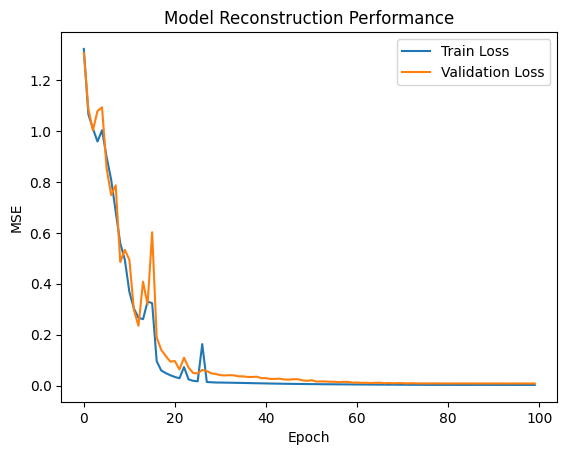

In [106]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Reconstruction Performance')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [107]:
# 1. Get predictions for the whole dataset
X_pred_scaled = model.predict([X_train, X_static])

# 2. Reshape 3D to 2D for the scaler
# (Flights * 31, 6)
X_train_2d = X_train.reshape(-1, len(features))
X_pred_2d = X_pred_scaled.reshape(-1, len(features))

# 3. Inverse Transform back to original units
X_train_orig = scaler.inverse_transform(X_train_2d)
X_pred_orig = scaler.inverse_transform(X_pred_2d)

# 4. Reshape back to 3D to keep flight sequences intact
X_train_final = X_train_orig.reshape(-1, 31, len(features))
X_pred_final = X_pred_orig.reshape(-1, 31, len(features))

ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 131766, 135342


In [ ]:
import pandas as pd

# We ignore the padding (-9.0) in our error calculation
# Create a mask where the original scaled data wasn't -9.0
mask = (X_train != -9.0)

mae_results = {}

for i, feature_name in enumerate(features):
    # Apply mask to both true and predicted arrays
    true_vals = X_train_final[:, :, i][mask[:, :, i]]
    pred_vals = X_pred_final[:, :, i][mask[:, :, i]]
    
    # Calculate Mean Absolute Error
    mae = np.mean(np.abs(true_vals - pred_vals))
    mae_results[feature_name] = mae

# Display results
mae_df = pd.Series(mae_results).rename("MAE (Original Units)")
print(mae_df)

press_hpa     34.816227
temp           3.810672
dpdp           3.071302
wspd           2.861246
wdir          51.142441
gph          842.624146
Name: MAE (Original Units), dtype: float32


In [ ]:
import pandas as pd

def inspect_flight_comparison(flight_idx, X_true_3d, X_pred_3d, scaler, features):
    # 1. Extract the specific 31-level flight
    true_slice = X_true_3d[flight_idx]
    pred_slice = X_pred_3d[flight_idx]
    
    # 2. Inverse scale both
    true_orig = scaler.inverse_transform(true_slice)
    pred_orig = scaler.inverse_transform(pred_slice)
    
    # 3. Create DataFrames
    df_true = pd.DataFrame(true_orig, columns=[f"{f}_true" for f in features])
    df_pred = pd.DataFrame(pred_orig, columns=[f"{f}_pred" for f in features])
    
    # 4. Filter out the padding rows (where pressure or GPH would be nonsensical)
    # We look at the 'true' data to see where the padding started
    mask = true_slice[:, 0] != -9.0
    
    # 5. Combine and reorder for easy comparison
    comparison_df = pd.concat([df_true, df_pred], axis=1).iloc[mask]
    
    # Optional: Reorder columns so 'temp_true' is next to 'temp_pred'
    ordered_cols = []
    for f in features:
        ordered_cols.extend([f"{f}_true", f"{f}_pred"])
    
    return comparison_df[ordered_cols]

# --- Execute for Flight #0 ---
flight_table = inspect_flight_comparison(0, X_train, X_pred_scaled, scaler, features)
print(f"Comparison for Flight Index 0 ({len(flight_table)} levels found):")
print(flight_table.head(10)) # Showing first 10 levels

Comparison for Flight Index 0 (4 levels found):
   press_hpa_true  press_hpa_pred  temp_true  temp_pred  dpdp_true  dpdp_pred  \
0           850.0      932.839722  15.800000  16.995058        0.7   4.051725   
1           700.0      809.057190   7.600001  11.560311        2.8   3.539681   
2           500.0      686.438171  -7.500000   4.852917        3.2   3.022553   
3           413.0      284.679810 -14.900000 -25.202478        3.2   2.801148   

   wspd_true  wspd_pred  wdir_true   wdir_pred     gph_true     gph_pred  
0        9.2   2.765730      260.0  238.676987  1473.999878  1374.937378  
1        5.1   3.215692      340.0  231.591858  3091.999756  1010.341125  
2        3.6   3.202405      135.0  227.211777  5780.000000  1873.292358  
3        2.0   1.597009      140.0  114.347366  7249.766602  5920.015137  
